# Two Stage Example

This is a two stage rocket example using the current version of RocketPy.

I'm aware better multi-stage support is expected in newer versions. This notebook is used only to figure out how to run a two stage rocket in the current version and prepare a list of what I think could be improved.

This is my first time using RocketPy. I work in the aerospace industry, but I only use trajectory data to develop loads, estimate vibration, size the launch vehicle structure.

I kept Andromeda's original mass properties despite changing it's size by adding a second stage motor. This is physically inaccurate because the complete vehicle, and the vehicle after the first stage is separated, have the same properties, which is impossible. In other words, this trajectory simulation is just fairy tale, and was done to check RocketPy's current capabilities for multiple stages.

Here a few points I noticed that are worth discussing/checking:

1. Important Suggestion: Add support for active control systems: roll control, actuated fins, thrust vector control...
2. Needed Feature: Two motors per rocket is currently not supported in the Rocket class.
3. Needed Feature: Necessary to add the interstage, forward, mid, aft modules in the Rocket class.
4. Question and possible needed feature: Does the software account for fins at multiple stages during aerodynamic calculation?
5. Possible bug: Small max_time argument (for example max_time=5) in Flight class cause the trajectory plot to show blank.
6. Question: Why is ProM2020.burn_time a tuple?
7. Suggestion: Make environment update between stages (different Flight class) automatic, updating the latitude, longitude, and elevation of the rocket for the second stage Flight class calculation.
8. Question and possible needed feature: Is gravity being updated with altitude?
9. Possible bug: The initial_solution list doesn't update the altitude. The second flight starts with altitude 0, despite Z being correct.
10. Possible bug: rail_length is supposed to be optional and not necessary if initial_solution is used in Flight class. This was not the case here. I had to use rail_length = 0.1 to force my simulation to run.

# Andromeda -  Aristotle Space and Aeronautics Team - 2022

Launched at EUROC'22. Achieved an apogee above 3400 meters, and the flight was nominal.
Permission to use flight data given by Antoniadis Panos, 2024.

In [235]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [236]:
import matplotlib.pyplot as plt

from rocketpy import Environment, Flight, Function, Rocket, SolidMotor

plt.style.use("seaborn-v0_8-colorblind")

## Environment registered by windy


Gravity Details

Acceleration of gravity at surface level:    9.8066 m/s²
Acceleration of gravity at   4.000 km (ASL): 9.8066 m/s²


Launch Site Details

Launch Date: 2022-10-14 13:00:00 UTC | 2022-10-14 14:00:00 Portugal
Launch Site Latitude: 39.38869°
Launch Site Longitude: -8.28781°
Reference Datum: WGS84
Launch Site UTM coordinates: 44507.97 W    4373270.52 N
Launch Site UTM zone: 30S
Launch Site Surface Elevation: 160.0 m


Atmospheric Model Details

Atmospheric Model Type: Reanalysis
Reanalysis Maximum Height: 4.000 km
Reanalysis Time Period: from 2022-10-13 10:00:00 to 2022-10-17 17:00:00 utc
Reanalysis Hour Interval: 2 hrs
Reanalysis Latitude Range: From 40.0° to 39.0°
Reanalysis Longitude Range: From -9.0° to -8.0°

Surface Atmospheric Conditions

Surface Wind Speed: 1.55 m/s
Surface Wind Direction: 309.52°
Surface Wind Heading: 129.52°
Surface Pressure: 1000.00 hPa
Surface Temperature: 298.89 K
Surface Air Density: 1.166 kg/m³
Surface Speed of Sound: 346.58 m/s


Earth Model

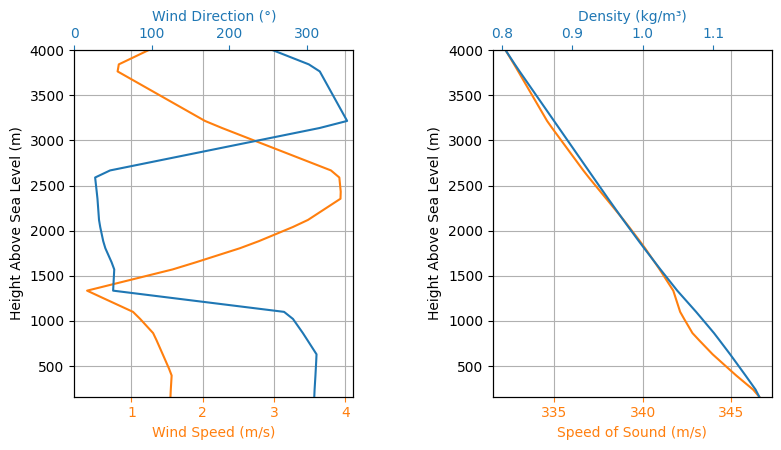

In [237]:
env = Environment(
    gravity=9.80665,
    date=(2022, 10, 14, 14),
    latitude=39.388692,
    longitude=-8.287814,
    elevation=160,
    datum="WGS84",
    timezone="Portugal",
)

env.set_atmospheric_model(
    type="Reanalysis",
    file="../../data/weather/euroc_2022_all_windows.nc",
    dictionary="ECMWF",
)
env.max_expected_height = 4000
env.info()

## Motor

Comment by Marcelo: I calculated the motor total length to adjust the vehicle size in the Rocket class, to make it a 2 stage vehicle.

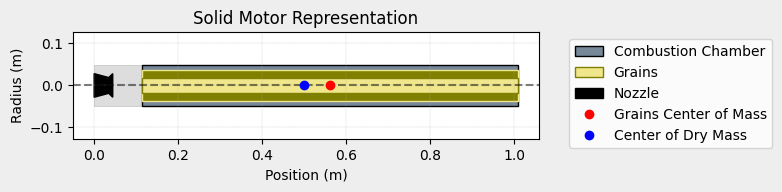

Solid Motor Total Length:  1.007890387225916
Nozzle Details
Nozzle Radius: 0.028125 m
Nozzle Throat Radius: 0.01875 m

Grain Details
Number of Grains: 1
Grain Spacing: 0 m
Grain Density: 1468.9079097925262 kg/m3
Grain Outer Radius: 0.0375 m
Grain Inner Radius: 0.01875 m
Grain Height: 0.893 m
Grain Volume: 0.003 m3
Grain Mass: 4.346 kg

Motor Details
Total Burning Time: 3.76 s
Total Propellant Mass: 4.346 kg
Structural Mass Ratio: 0.000
Average Propellant Exhaust Velocity: 2270.131 m/s
Average Thrust: 2624.114 N
Maximum Thrust: 3347.670162 N at 1.106 s after ignition.
Total Impulse: 9866.669 Ns



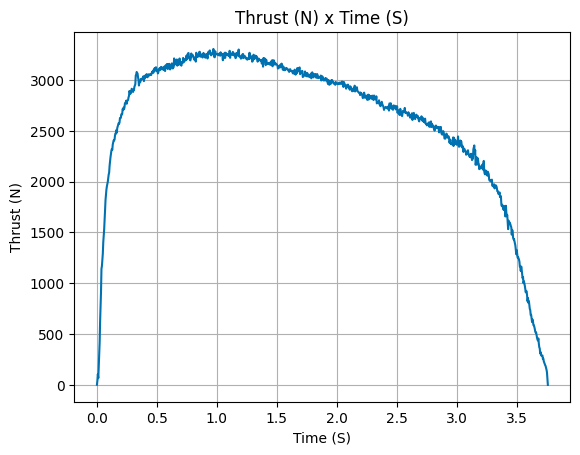

In [238]:
ProM2020 = SolidMotor(
    # thrust_source="../../data/motors/cesaroni/Cesaroni_8429M2020-P.eng",
    thrust_source="../../data/rockets/andromeda/thrust_curve.csv",
    burn_time=3.76,
    grain_number=1,
    grain_density=1468.9079097925262,
    grain_initial_inner_radius=0.01875,
    grain_outer_radius=0.0375,
    grain_initial_height=0.893,
    nozzle_radius=0.028125,
    nozzle_position=0,
    throat_radius=0.01875,
    grain_separation=0,
    grains_center_of_mass_position=0.5613903872259161,
    dry_inertia=(0, 0, 0),
    center_of_dry_mass_position=0.5,
    dry_mass=0,
)
ProM2020.draw()

# Total length of the motor will be added to the rocket's geometry to simulate an equal second stage.
ProM2020.motor_total_length = ProM2020.grains_center_of_mass_position + 0.5*ProM2020.grain_initial_height
print("Solid Motor Total Length: ", ProM2020.motor_total_length) 
ProM2020.info()



## First Stage (Complete Vehicle)
Changed the original Andromeda geometry by adding a motor and a set of fins. I did not update mass and inertia properties due to lack of time.

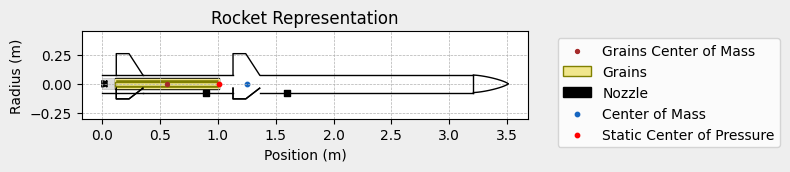


Inertia Details

Rocket Mass: 20.977 kg (without motor)
Rocket Dry Mass: 20.977 kg (with unloaded motor)
Rocket Loaded Mass: 25.323 kg
Rocket Structural Mass Ratio: 0.828
Rocket Inertia (with unloaded motor) 11: 11.249 kg*m2
Rocket Inertia (with unloaded motor) 22: 11.249 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.124 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.07535 m
Rocket Frontal Area: 0.017837 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 1.400 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.838 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.144 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 9.255/rad
Fins Lift Coefficient

In [239]:
Andromeda_First = Rocket(
    radius=0.07535,
    mass=20.9767,
    inertia=(11.249, 11.249, 0.12377),
    center_of_mass_without_motor=1.3998,
    power_off_drag="../../data/rockets/andromeda/drag_coefficient.csv",
    power_on_drag="../../data/rockets/andromeda/drag_coefficient.csv",
    coordinate_system_orientation="tail_to_nose",
)

Andromeda_First.set_rail_buttons(1.5998, 0.8998)

Andromeda_First.add_motor(ProM2020, position=0)

NoseCone = Andromeda_First.add_nose(
    length=0.3,
    kind="vonKarman",
    position=2.4996 + ProM2020.motor_total_length,
)

FinSet_First = Andromeda_First.add_trapezoidal_fins(
    n=3,
    span=0.185,
    root_chord=0.23,
    tip_chord=0.11,
    position=0.3546,
)

FinSet_Second = Andromeda_First.add_trapezoidal_fins(
    n=3,
    span=0.185,
    root_chord=0.23,
    tip_chord=0.11,
    position=0.3546 + ProM2020.motor_total_length,
)

Drogue = Andromeda_First.add_parachute(
    "Drogue", cd_s=0.84665922014, trigger="apogee", sampling_rate=100, lag=0
)

Main = Andromeda_First.add_parachute(
    "Main", cd_s=8.362919643856031, trigger=500, sampling_rate=100, lag=0
)

Andromeda_First.draw()
Andromeda_First.prints.all()

## Second Stage (Vehicle After First Stage is Separated)
Kepth the original Andromeda geometry.

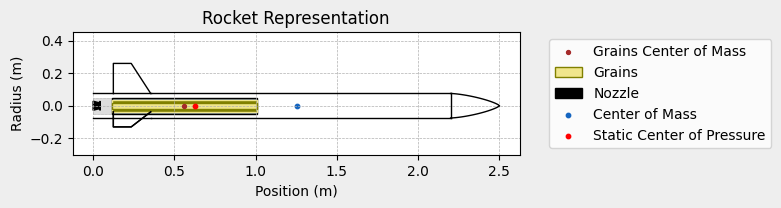


Inertia Details

Rocket Mass: 20.977 kg (without motor)
Rocket Dry Mass: 20.977 kg (with unloaded motor)
Rocket Loaded Mass: 25.323 kg
Rocket Structural Mass Ratio: 0.828
Rocket Inertia (with unloaded motor) 11: 11.249 kg*m2
Rocket Inertia (with unloaded motor) 22: 11.249 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.124 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.07535 m
Rocket Frontal Area: 0.017837 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 1.400 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.838 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.144 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 9.255/rad

Center of Pressure



In [240]:
Andromeda_Second = Rocket(
    radius=0.07535,
    mass=20.9767,
    inertia=(11.249, 11.249, 0.12377),
    center_of_mass_without_motor=1.3998,
    power_off_drag="../../data/rockets/andromeda/drag_coefficient.csv",
    power_on_drag="../../data/rockets/andromeda/drag_coefficient.csv",
    coordinate_system_orientation="tail_to_nose",
)

Andromeda_Second.add_motor(ProM2020, position=0)

NoseCone = Andromeda_Second.add_nose(
    length=0.3,
    kind="vonKarman",
    position=2.4996,
)

FinSet_First = Andromeda_Second.add_trapezoidal_fins(
    n=3,
    span=0.185,
    root_chord=0.23,
    tip_chord=0.11,
    position=0.3546,
)

Drogue = Andromeda_Second.add_parachute(
    "Drogue", cd_s=0.84665922014, trigger="apogee", sampling_rate=100, lag=0
)

Main = Andromeda_Second.add_parachute(
    "Main", cd_s=8.362919643856031, trigger=500, sampling_rate=100, lag=0
)

Andromeda_Second.draw()
Andromeda_Second.prints.all()


## First Stage Flight Simulation

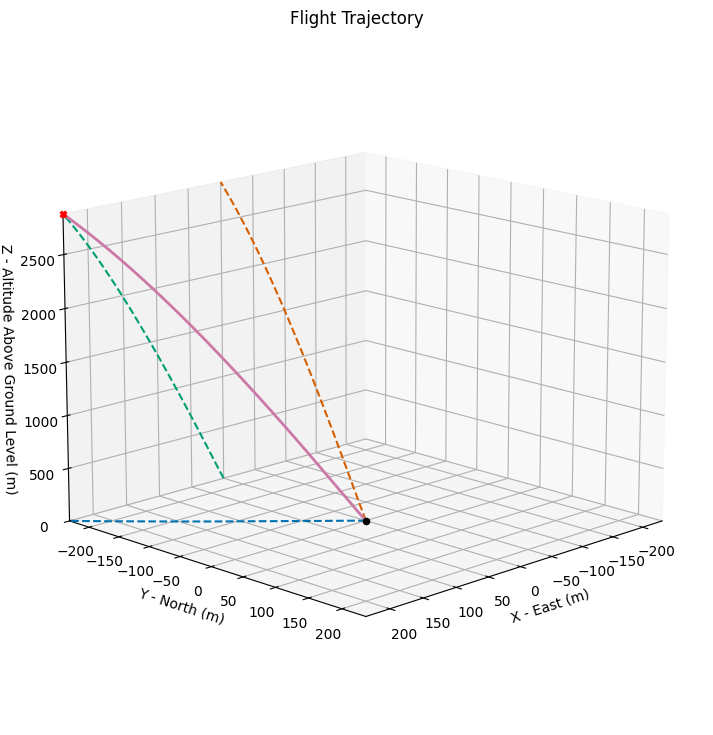

In [241]:
ignition_delay = 10 #First stage flight continues for 10 seconds after motor burnout before the second stage ignites.
first_flight_duration = ProM2020.burn_time[1] + ignition_delay

test_flight = Flight(
    rocket=Andromeda_First,
    environment=env,
    inclination=84,
    heading=133,
    rail_length=12,
    max_time = first_flight_duration
)

test_flight.plots.trajectory_3d()

## Second Stage Flight Simulation


Gravity Details

Acceleration of gravity at surface level:    9.8066 m/s²
Acceleration of gravity at   6.000 km (ASL): 9.8066 m/s²


Launch Site Details

Launch Date: 2022-10-14 13:00:00 UTC | 2022-10-14 14:00:00 Portugal
Launch Site Latitude: 39.38869°
Launch Site Longitude: -8.28781°
Reference Datum: WGS84
Launch Site UTM coordinates: 44507.97 W    4373270.52 N
Launch Site UTM zone: 30S
Launch Site Surface Elevation: 160.0 m


Atmospheric Model Details

Atmospheric Model Type: Reanalysis
Reanalysis Maximum Height: 6.000 km
Reanalysis Time Period: from 2022-10-13 10:00:00 to 2022-10-17 17:00:00 utc
Reanalysis Hour Interval: 2 hrs
Reanalysis Latitude Range: From 40.0° to 39.0°
Reanalysis Longitude Range: From -9.0° to -8.0°

Surface Atmospheric Conditions

Surface Wind Speed: 1.55 m/s
Surface Wind Direction: 309.52°
Surface Wind Heading: 129.52°
Surface Pressure: 1000.00 hPa
Surface Temperature: 298.89 K
Surface Air Density: 1.166 kg/m³
Surface Speed of Sound: 346.58 m/s


Earth Model

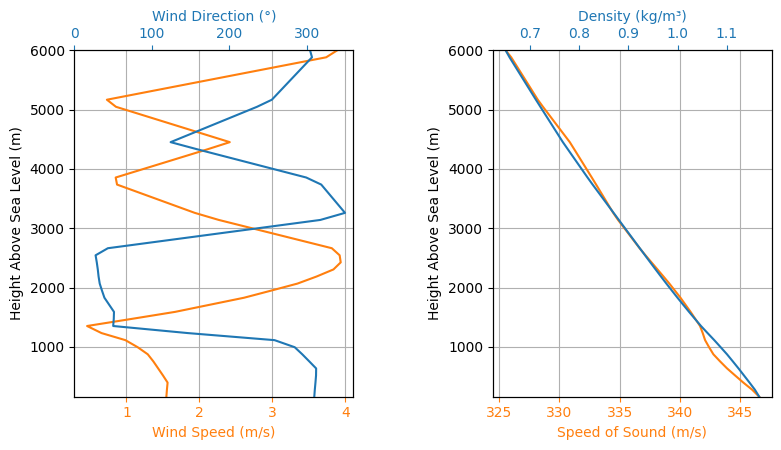

In [245]:
second_initial_elevation = test_flight.z(first_flight_duration)
second_initial_latitude = test_flight.latitude(first_flight_duration)
second_initial_longitude = test_flight.longitude(first_flight_duration)

env2 = Environment(
    gravity=9.80665,
    date=(2022, 10, 14, 14),
    latitude=second_initial_latitude,
    longitude=second_initial_longitude,
    elevation=second_initial_elevation,
    datum="WGS84",
    timezone="Portugal",
)

env2.set_atmospheric_model(
    type="Reanalysis",
    file="../../data/weather/euroc_2022_all_windows.nc",
    dictionary="ECMWF",
)
env.max_expected_height = 6000
env.info()


Apogee State

Apogee Time: 25.844 s
Apogee Altitude: 3776.045 m (ASL) | 743.952 m (AGL)
Apogee Freestream Speed: 17.712 m/s
Apogee X position: 396.123 m
Apogee Y position: -406.077 m
Apogee latitude: 39.3829402°
Apogee longitude: -8.2804686°


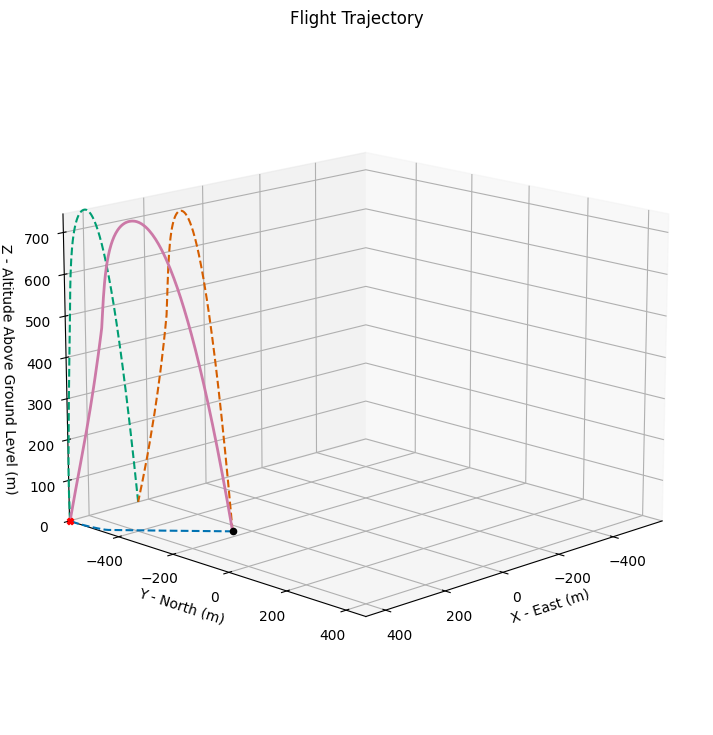

In [246]:
# Second Stage Flight

flight_second = Flight(
    rocket=Andromeda_Second,
    environment=env2,
    rail_length=0.01, # This should be optional, but removing it gave an error
    initial_solution = [
    first_flight_duration,
    test_flight.x(first_flight_duration), test_flight.y(first_flight_duration), test_flight.z(first_flight_duration),
    test_flight.vx(first_flight_duration), test_flight.vy(first_flight_duration), test_flight.vz(first_flight_duration),
    test_flight.e0(first_flight_duration), test_flight.e1(first_flight_duration), test_flight.e2(first_flight_duration), test_flight.e3(first_flight_duration),
    test_flight.w1(first_flight_duration), test_flight.w2(first_flight_duration), test_flight.w3(first_flight_duration)
])

flight_second.prints.apogee_conditions()
flight_second.plots.trajectory_3d()

Notice the plot above starts with altitude 0. This seems to be a bug, or maybe I'm doing something wrong. Plots below show that adding final altitude from the first flight to the results of the second Flight class result in a continuous plot.

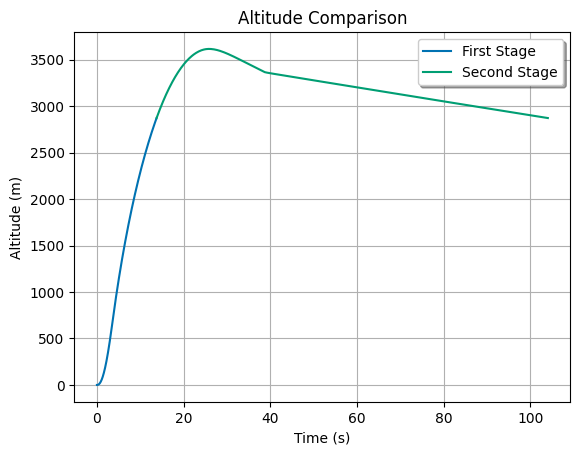

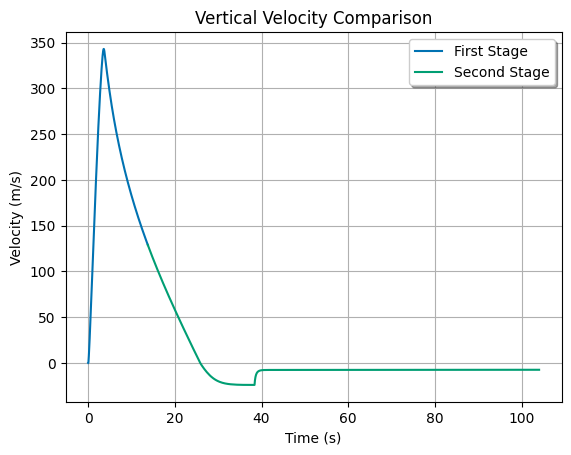

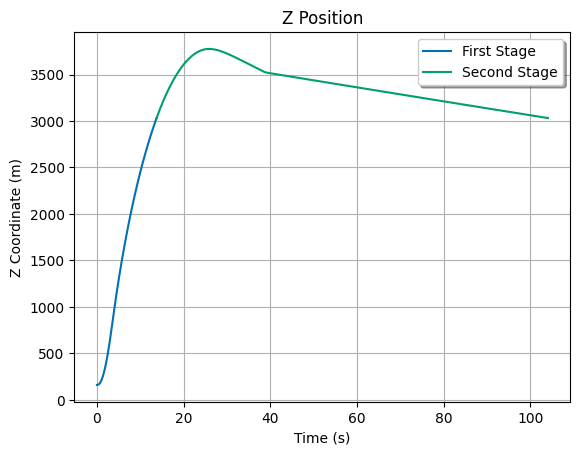

In [ ]:
Function.compare_plots(
    [
        (test_flight.altitude, "First Stage"),
        (flight_second.altitude + test_flight.altitude(first_flight_duration), "Second Stage"), # Had to add the initial altitude manually. It should be updated automatically.
    ],
    title="Altitude Comparison",
    xlabel="Time (s)",
    ylabel="Altitude (m)",
)

Function.compare_plots(
    [
        (test_flight.vz, "First Stage"),
        (flight_second.vz, "Second Stage"),
    ],
    title="Vertical Velocity Comparison",
    xlabel="Time (s)",
    ylabel="Velocity (m/s)",
)

Function.compare_plots(
    [
        (test_flight.z, "First Stage"),
        (flight_second.z, "Second Stage"), # Z coordinate is working properly. Only the initial altitude wasn't updated.
    ],
    title="Z Position",
    xlabel="Time (s)",
    ylabel="Z Coord. (m)",
)